In [2]:
# projektowanie algorytmów lista 9 Oliwia Borkowska

# tak jak w liście 8 - lista robotów:

import random
import csv

TYP = ["AGV", "AFV", "ASV", "AUV"]

def generuj_losowego_robota():
    typ = random.choice(TYP)
    cena = round(random.uniform(0, 10000), 2)
    zasieg = random.randint(0, 100)
    kamera = random.choice([0, 1])
    return (typ, cena, zasieg, kamera)

def generuj_liste_robotow(N):
    lista_robotow = []
    for _ in range(N):
        lista_robotow.append(generuj_losowego_robota())
    return lista_robotow

def wyswietl_liste_robotow(lista_robotow):
    print(f"{'TYP':<5} {'CENA':>10} {'ZASIĘG':>10} {'KAMERA':>10}")
    print("-" * 40)
    for robot in lista_robotow:
        typ, cena, zasieg, kamera = robot
        print(f"{typ:<5} {cena:>10.2f} {zasieg:>10} {kamera:>10}")

def zapisz_do_pliku(lista_robotow, nazwa_pliku):
    with open(nazwa_pliku, "w", newline='') as plik:
        writer = csv.writer(plik)
        writer.writerow(["TYP", "CENA", "ZASIEG", "KAMERA"])
        writer.writerows(lista_robotow)

def odczytaj_z_pliku(nazwa_pliku):
    lista_robotow = []
    with open(nazwa_pliku, "r", newline='') as plik:
        reader = csv.reader(plik)
        next(reader)
        for wiersz in reader:
            typ = wiersz[0]
            cena = float(wiersz[1])
            zasieg = int(wiersz[2])
            kamera = int(wiersz[3])
            lista_robotow.append((typ, cena, zasieg, kamera))
    return lista_robotow

if __name__ == "__main__":
    N = int(input("Podaj liczbę robotów do wygenerowania i zapisania na liście: "))
    lista = generuj_liste_robotow(N)

    print("Lista robotów:")
    wyswietl_liste_robotow(lista)

    nazwa_pliku = "lista_robotow.csv"
    zapisz_do_pliku(lista, nazwa_pliku)
    print(f"\n\nLista robotów została zapisana do pliku '{nazwa_pliku}'.")

    print(f"\n\nOdczytana lista robotów z pliku '{nazwa_pliku}':")
    lista_z_pliku = odczytaj_z_pliku(nazwa_pliku)
    wyswietl_liste_robotow(lista_z_pliku)


Lista robotów:
TYP         CENA     ZASIĘG     KAMERA
----------------------------------------
ASV       398.23         23          0
ASV      9412.86         27          0
AUV      6177.77         80          1
AFV      2371.24         52          0
AGV      7205.69          6          1


Lista robotów została zapisana do pliku 'lista_robotow.csv'.


Odczytana lista robotów z pliku 'lista_robotow.csv':
TYP         CENA     ZASIĘG     KAMERA
----------------------------------------
ASV       398.23         23          0
ASV      9412.86         27          0
AUV      6177.77         80          1
AFV      2371.24         52          0
AGV      7205.69          6          1


In [22]:
# Zadanie 1 - wyszukiwanie liniowe

import csv

def wczytaj_robota_z_pliku(sciezka):
    lista_robotow = []
    with open(sciezka, newline='', encoding='utf-8') as plik:
        reader = csv.DictReader(plik)
        for wiersz in reader:
            typ = wiersz['TYP']
            cena = float(wiersz['CENA'])
            zasieg = int(wiersz['ZASIEG'])
            kamera = int(wiersz['KAMERA'])
            robot = (typ, cena, zasieg, kamera)
            lista_robotow.append(robot)
    return lista_robotow

def wczytaj_kryterium(parametr_name):
    inp = input(f"Wpisz kryterium dla {parametr_name} (pojedyncza poszukiwana wartość, lista wartości rozdzielona przecinkami lub Enter, czyli dowolna wartość): ").strip()
    if inp == '':
        return None
    if parametr_name in ['CENA', 'ZASIEG', 'KAMERA']:
        lista_wartosci = [x.strip() for x in inp.split(',')]
        wynik = []
        for wart in lista_wartosci:
            try:
                if parametr_name == 'CENA':
                    wynik.append(float(wart))
                else:
                    wynik.append(int(wart))
            except ValueError:
                print(f"Wporwadzona wartość '{wart}' dla parametru {parametr_name} jest niepoprawna, zostaje pominięta.")
        if len(wynik) == 1:
            return wynik[0]
        elif len(wynik) > 1:
            return wynik
        else:
            return None
    else:
        lista_wartosci = [x.strip() for x in inp.split(',')]
        if len(lista_wartosci) == 1:
            return lista_wartosci[0]
        else:
            return lista_wartosci

def pasuje(robot, kryteria):
    for i, kryt in enumerate(kryteria):
        if kryt is None:
            continue
        wartosc = robot[i]
        if isinstance(kryt, list):
            if wartosc not in kryt:
                return False
        else:
            if wartosc != kryt:
                return False
    return True

def wyszukaj_robota(lista_robotow, kryteria):
    for robot in lista_robotow:
        if pasuje(robot, kryteria):
            return robot
    return None

def wyswietl_robota(robot):
    if robot is None:
        print("Brak robota spełniającego wybrane kryteria.")
    else:
        typ, cena, zasieg, kamera = robot
        print(f"Znaleziony robot: TYP: {typ}, CENA: {cena} PLN, ZASIĘG: {zasieg} km, KAMERA: {kamera}")

def main():
    nazwa_pliku = input("Podaj nazwę pliku CSV z listą robotów: ").strip()
    if not nazwa_pliku:
        nazwa_pliku = "lista_robotow.csv"
    try:
        lista_robotow = wczytaj_robota_z_pliku(nazwa_pliku)
    except Exception as e:
        print(f"Błąd podczas wczytywania pliku: {e}")
        return

    print(f"Wczytano {len(lista_robotow)} robotów z pliku '{nazwa_pliku}'.")
    
    while True:
        print("Wybierz opcję:")
        print("1 - Wyszukaj robota")
        print("2 - Zakończ program")
        wybor = input("Twój wybór: 1 - Wyszukaj robota lub 0 - Zakończ program").strip()
        
        if wybor == "1":
            print("Wprowadź kryteria wyszukiwania robota:")
            typ = wczytaj_kryterium('TYP')
            cena = wczytaj_kryterium('CENA')
            zasieg = wczytaj_kryterium('ZASIEG')
            kamera = wczytaj_kryterium('KAMERA')

            kryteria = (typ, cena, zasieg, kamera)
            wynik = wyszukaj_robota(lista_robotow, kryteria)
            wyswietl_robota(wynik)
        
        elif wybor == "0":
            print("Zakończono program.")
            break
        
        else:
            print("Wybór jest niepoprawny. Spróbuj ponownie.")

if __name__ == "__main__":
    main()

Wczytano 5 robotów z pliku 'lista_robotow.csv'.
Wybierz opcję:
1 - Wyszukaj robota
2 - Zakończ program
Wprowadź kryteria wyszukiwania robota:
Znaleziony robot: TYP: ASV, CENA: 398.23 PLN, ZASIĘG: 23 km, KAMERA: 0
Wybierz opcję:
1 - Wyszukaj robota
2 - Zakończ program
Zakończono program.


In [23]:
# Zadanie 2 - wyszukiwanie binarne

import csv

def wczytaj_robota_z_pliku(sciezka):
    lista_robotow = []
    with open(sciezka, newline='', encoding='utf-8') as plik:
        reader = csv.DictReader(plik)
        for wiersz in reader:
            typ = wiersz['TYP']
            cena = float(wiersz['CENA'])
            zasieg = int(wiersz['ZASIEG'])
            kamera = int(wiersz['KAMERA'])
            robot = (typ, cena, zasieg, kamera)
            lista_robotow.append(robot)
    return lista_robotow

def wczytaj_parametr():
    while True:
        param = input("Wybierz parametr do wyszukiwania (TYP, CENA, ZASIEG, KAMERA): ").strip().upper()
        if param in ["TYP", "CENA", "ZASIEG", "KAMERA"]:
            return param
        else:
            print("Niepoprawny parametr. Spróbuj ponownie.")

def wczytaj_wartosci_parametru(param):
    inp = input(f"Wpisz listę wartości dla parametru {param} (oddzielone przecinkami, bez nawiasów kwadratowych): ").strip()
    lista = [x.strip() for x in inp.split(",")]
    wynik = []
    for x in lista:
        try:
            if param == "CENA":
                wynik.append(float(x))
            elif param in ["ZASIEG", "KAMERA"]:
                wynik.append(int(x))
            else:
                wynik.append(x)
        except ValueError:
            print(f"Niepoprawna wartość: {x} - pomijam.")
    return wynik


def indeks_parametru(param):
    slownik = {"TYP": 0, "CENA": 1, "ZASIEG": 2, "KAMERA": 3}
    return slownik[param]

def wyszukiwanie_binarne(lista, wartosc, indeks):
    lewy = 0
    prawy = len(lista) - 1
    while lewy <= prawy:
        srodkowy = (lewy + prawy) // 2
        if lista[srodkowy][indeks] == wartosc:
            while srodkowy > 0 and lista[srodkowy-1][indeks] == wartosc:
                srodkowy -= 1
            return lista[srodkowy]
        elif lista[srodkowy][indeks] < wartosc:
            lewy = srodkowy + 1
        else:
            prawy = srodkowy - 1
    return None

def wyszukaj_robota_binarnie(lista_robotow, param, wartosci):
    indeks = indeks_parametru(param)
    lista_robotow.sort(key=lambda x: x[indeks])
    
    print("\nPosortowana lista robotów:")
    for robot in lista_robotow:
        print(f"TYP: {robot[0]}, CENA: {robot[1]} PLN, ZASIĘG: {robot[2]} km, KAMERA: {robot[3]}")
    
    for wart in wartosci:
        robot = wyszukiwanie_binarne(lista_robotow, wart, indeks)
        if robot is not None:
            return robot
    return None

def wyswietl_robota(robot):
    if robot is None:
        print("Nie ma robota spełniającego podane kryteria.")
    else:
        typ, cena, zasieg, kamera = robot
        print(f"\nZnaleziono robota: TYP: {typ}, CENA: {cena} PLN, ZASIĘG: {zasieg} km, KAMERA: {kamera}")

def main():
    nazwa_pliku = input("Podaj nazwę pliku CSV z listą robotów: ").strip()
    if not nazwa_pliku:
        nazwa_pliku = "lista_robotow.csv"
    try:
        lista_robotow = wczytaj_robota_z_pliku(nazwa_pliku)
    except Exception as e:
        print(f"Błąd podczas wczytywania pliku: {e}")
        return

    print(f"Wczytano {len(lista_robotow)} robotów z pliku '{nazwa_pliku}'.")

    while True:
        print("\nWybierz opcję:")
        print("1 - Wyszukaj robota (wyszukiwanie binarne)")
        print("2 - Zakończ program")
        wybor = input("Twój wybór: 1 - Wyszukaj robota lub 0 - Zakończ program").strip()

        if wybor == "1":
            param = wczytaj_parametr()
            wartosci = wczytaj_wartosci_parametru(param)
            wynik = wyszukaj_robota_binarnie(lista_robotow, param, wartosci)
            wyswietl_robota(wynik)

        elif wybor == "0":
            print("Zakończono program.")
            break

        else:
            print("Wybór jest niepoprawny. Spróbuj ponownie.")

if __name__ == "__main__":
    main()

Wczytano 5 robotów z pliku 'lista_robotow.csv'.

Wybierz opcję:
1 - Wyszukaj robota (wyszukiwanie binarne)
2 - Zakończ program

Posortowana lista robotów:
TYP: ASV, CENA: 398.23 PLN, ZASIĘG: 23 km, KAMERA: 0
TYP: AFV, CENA: 2371.24 PLN, ZASIĘG: 52 km, KAMERA: 0
TYP: AUV, CENA: 6177.77 PLN, ZASIĘG: 80 km, KAMERA: 1
TYP: AGV, CENA: 7205.69 PLN, ZASIĘG: 6 km, KAMERA: 1
TYP: ASV, CENA: 9412.86 PLN, ZASIĘG: 27 km, KAMERA: 0
Nie ma robota spełniającego podane kryteria.

Wybierz opcję:
1 - Wyszukaj robota (wyszukiwanie binarne)
2 - Zakończ program
Zakończono program.


In [26]:
# Zadanie 3 - metoda łańcuchowa

import csv

def wczytaj_robota_z_pliku(sciezka):
    lista_robotow = []
    with open(sciezka, newline='', encoding='utf-8') as plik:
        reader = csv.DictReader(plik)
        for wiersz in reader:
            typ = wiersz['TYP']
            cena = float(wiersz['CENA'])
            zasieg = int(wiersz['ZASIEG'])
            kamera = int(wiersz['KAMERA'])
            robot = (typ, cena, zasieg, kamera)
            lista_robotow.append(robot)
    return lista_robotow

def indeks_parametru(param):
    slownik = {"TYP": 0, "CENA": 1, "ZASIEG": 2, "KAMERA": 3}
    return slownik[param]

def obliczanie_rozmiar_tablicy(n, alpha):
    return max(1, int(n / alpha))

def generowanie_klucza(wartosc, rozmiar_tablicy):
    if isinstance(wartosc, (int, float)):
        return int(wartosc * 100) % rozmiar_tablicy
    else:
        return sum(ord(c) for c in str(wartosc)) % rozmiar_tablicy

def wstawianie_do_tablicy(tablica, robot, param_idx):
    wartosc = robot[param_idx]
    indeks = generowanie_klucza(wartosc, len(tablica))
    tablica[indeks].append(robot)

def wyszukiwanie_w_tablicy(tablica, param_idx, wartosc):
    indeks = generowanie_klucza(wartosc, len(tablica))
    for robot in tablica[indeks]:
        if robot[param_idx] == wartosc:
            return robot
    return None

def wyswietlanie_robota(robot):
    if robot is None:
        print("Nie ma robota spełniającego kryteria.")
    else:
        typ, cena, zasieg, kamera = robot
        print(f"Znaleziony robot: TYP: {typ}, CENA: {cena} PLN, ZASIĘG: {zasieg} km, KAMERA: {kamera}")

def main():
    nazwa_pliku = input("Podaj nazwę pliku CSV z listą robotów: ").strip()
    if not nazwa_pliku:
        nazwa_pliku = "lista_robotow.csv"
    try:
        lista_robotow = wczytaj_robota_z_pliku(nazwa_pliku)
    except Exception as e:
        print(f"Błąd podczas wczytywania pliku: {e}")
        return

    n = len(lista_robotow)
    print(f"Wczytano {n} robotów z pliku '{nazwa_pliku}'.")

    while True:
        print("\nWybierz opcję:")
        print("1 - Wyszukaj robota (metoda łańcuchowa)")
        print("0 - Zakończ program")
        wybor = input("Twój wybór: 1 - Wyszukaj robota lub 0 - Zakończ program").strip()

        if wybor == "1":
            try:
                alpha = float(input("Podaj współczynnik wypełnienia tablicy (np. 0.25): ").strip())
                if alpha <= 0 or alpha > 1:
                    print("Współczynnik alpha musi być z przedziału (0, 1].")
                    continue
            except:
                print("Współczynnik jest niepoprawny. Spróbuj ponownie.")
                continue

            M = obliczanie_rozmiar_tablicy(n, alpha)
            tablica = [[] for _ in range(M)]
            param = input("Wybierz parametr do wyszukiwania (TYP, CENA, ZASIEG, KAMERA): ").strip().upper()
            if param not in ["TYP", "CENA", "ZASIEG", "KAMERA"]:
                print("Niepoprawny parametr.")
                continue
            param_idx = indeks_parametru(param)

            for robot in lista_robotow:
                wstawianie_do_tablicy(tablica, robot, param_idx)

            if param == "CENA":
                wartosc = float(input("Podaj wartość szukanego parametru: ").strip())
            elif param in ["ZASIEG", "KAMERA"]:
                wartosc = int(input("Podaj wartość szukanego parametru: ").strip())
            else:
                wartosc = input("Podaj wartość szukanego parametru: ").strip()

            wynik = wyszukiwanie_w_tablicy(tablica, param_idx, wartosc)
            wyswietl_robota(wynik)

        elif wybor == "0":
            print("Zakończono program.")
            break
        else:
            print("Wybór jest niepoprawny. Spróbuj ponownie.")

if __name__ == "__main__":
    main()

Wczytano 5 robotów z pliku 'lista_robotow.csv'.

Wybierz opcję:
1 - Wyszukaj robota (metoda łańcuchowa)
0 - Zakończ program

Znaleziono robota: TYP: ASV, CENA: 398.23 PLN, ZASIĘG: 23 km, KAMERA: 0

Wybierz opcję:
1 - Wyszukaj robota (metoda łańcuchowa)
0 - Zakończ program
Zakończono program.


In [27]:
# Zadanie 4 - adresowanie otwarte

import csv

def wczytaj_robota_z_pliku(sciezka):
    roboty = []
    with open(sciezka, newline='', encoding='utf-8') as plik:
        reader = csv.DictReader(plik)
        for wiersz in reader:
            typ = wiersz['TYP']
            cena = float(wiersz['CENA'])
            zasieg = int(wiersz['ZASIEG'])
            kamera = int(wiersz['KAMERA'])
            robot = (typ, cena, zasieg, kamera)
            roboty.append(robot)
    return roboty

def indeks_parametru(param):
    slownik = {"TYP": 0, "CENA": 1, "ZASIEG": 2, "KAMERA": 3}
    return slownik[param]

def obliczanie_rozmiar_tablicy(n, alpha):
    return max(1, int(n / alpha))

def generowanie_klucza(wartosc):
    if isinstance(wartosc, (int, float)):
        return int(wartosc) % 1000
    else:
        return sum(ord(c) for c in str(wartosc)) % 1000

def funkcja_haszujaca(klucz, i, m):
    c1 = 1
    c2 = 3
    return (klucz + c1 * i + c2 * i**2) % m

def wstawianie_do_tablicy(tablica, robot, param_idx):
    wartosc = robot[param_idx]
    klucz = generowanie_klucza(wartosc)
    m = len(tablica)
    for i in range(m):
        indeks = funkcja_haszujaca(klucz, i, m)
        if tablica[indeks] is None:
            tablica[indeks] = robot
            return
    print("Brak miejsca w tablicy – współczynnik  jest zbyt wysoki lub parametry haszowania są nieprawidłowe!")

def wyszukaj_w_tablicy(tablica, param_idx, wartosc):
    klucz = generowanie_klucza(wartosc)
    m = len(tablica)
    for i in range(m):
        indeks = funkcja_haszujaca(klucz, i, m)
        robot = tablica[indeks]
        if robot is None:
            return None
        if robot[param_idx] == wartosc:
            return robot
    return None

def wyswietlanie_robota(robot):
    if robot is None:
        print("Nie ma robota spełniającego kryteria.")
    else:
        typ, cena, zasieg, kamera = robot
        print(f"Znaleziony robot: TYP: {typ}, CENA: {cena} PLN, ZASIĘG: {zasieg} km, KAMERA: {kamera}")

def main():
    nazwa_pliku = input("Podaj nazwę pliku CSV z listą robotów: ").strip()
    if not nazwa_pliku:
        nazwa_pliku = "lista_robotow.csv"
    try:
        lista_robotow = wczytaj_robota_z_pliku(nazwa_pliku)
    except Exception as e:
        print(f"Błąd podczas wczytywania pliku: {e}")
        return

    n = len(lista_robotow)
    print(f"Wczytano {n} robotów z pliku '{nazwa_pliku}'.")

    while True:
        print("\nWybierz opcję:")
        print("1 - Wyszukaj robota (adresowanie otwarte kwadratowe)")
        print("0 - Zakończ program")
        wybor = input("Twój wybór: 1 - Wyszukaj robota lub 0 - Zakończ program").strip()

        if wybor == "1":
            try:
                alpha = float(input("Podaj współczynnik wypełnienia tablicy alpha (np. 0.25): ").strip())
                if alpha <= 0 or alpha > 1:
                    print("Współczynnik alpha musi być z przedziału (0, 1]. Spróbuj ponownie.")
                    continue
            except ValueError:
                print("Niepoprawny współczynnik. Spróbuj ponownie.")
                continue

            M = obliczanie_rozmiar_tablicy(n, alpha)
            tablica = [None] * M

            param = input("Wybierz parametr do wyszukiwania (TYP, CENA, ZASIEG, KAMERA): ").strip().upper()
            if param not in ["TYP", "CENA", "ZASIEG", "KAMERA"]:
                print("Niepoprawny parametr. Spróbuj ponownie.")
                continue
            param_idx = indeks_parametru(param)

            for robot in lista_robotow:
                wstawianie_do_tablicy(tablica, robot, param_idx)

            if param == "CENA":
                try:
                    wartosc = float(input("Podaj wartość szukanego parametru: ").strip())
                except ValueError:
                    print("Niepoprawna wartość. Spróbuj ponownie.")
                    continue
            elif param in ["ZASIEG", "KAMERA"]:
                try:
                    wartosc = int(input("Podaj wartość szukanego parametru: ").strip())
                except ValueError:
                    print("Niepoprawna wartość. Spróbuj ponownie.")
                    continue
            else:
                wartosc = input("Podaj wartość szukanego parametru: ").strip()

            wynik = wyszukaj_w_tablicy(tablica, param_idx, wartosc)
            wyswietl_robota(wynik)

        elif wybor == "0":
            print("Zakończono program.")
            break
        else:
            print("Niepoprawny wybór. Spróbuj ponownie.")

if __name__ == "__main__":
    main()

Wczytano 5 robotów z pliku 'lista_robotow.csv'.

Wybierz opcję:
1 - Wyszukaj robota (adresowanie otwarte kwadratowe)
0 - Zakończ program

Znaleziono robota: TYP: ASV, CENA: 398.23 PLN, ZASIĘG: 23 km, KAMERA: 0

Wybierz opcję:
1 - Wyszukaj robota (adresowanie otwarte kwadratowe)
0 - Zakończ program
Zakończono program.


Wczytano 5 robotów z pliku 'lista_robotow.csv'.
alpha=0.05, n=5, M=100 (rozmiar tablicy)
alpha=0.10, n=5, M=50 (rozmiar tablicy)
alpha=0.15, n=5, M=33 (rozmiar tablicy)
alpha=0.20, n=5, M=25 (rozmiar tablicy)
alpha=0.25, n=5, M=20 (rozmiar tablicy)
alpha=0.30, n=5, M=16 (rozmiar tablicy)
alpha=0.35, n=5, M=14 (rozmiar tablicy)
alpha=0.40, n=5, M=12 (rozmiar tablicy)
alpha=0.45, n=5, M=11 (rozmiar tablicy)
alpha=0.50, n=5, M=10 (rozmiar tablicy)
alpha=0.55, n=5, M=9 (rozmiar tablicy)
alpha=0.60, n=5, M=8 (rozmiar tablicy)
alpha=0.65, n=5, M=7 (rozmiar tablicy)
alpha=0.70, n=5, M=7 (rozmiar tablicy)
alpha=0.75, n=5, M=6 (rozmiar tablicy)
Błąd przy alfa=0.75: Tablica jest pełna, nie można wstawić już elementu


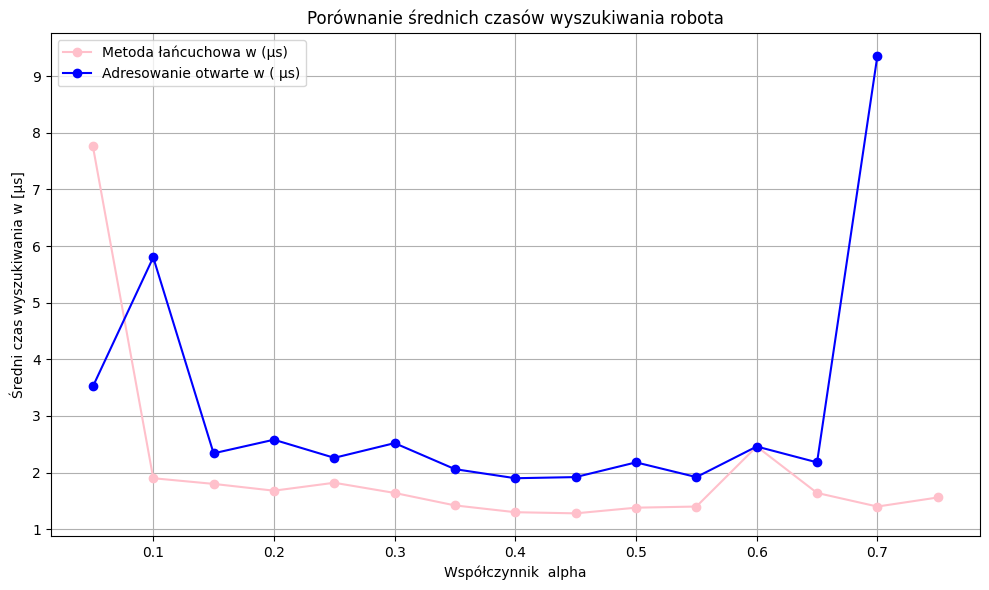

In [21]:
# Zadanie 5 - zestawienie algorytmów

import csv
import time
import matplotlib.pyplot as plt
import numpy as np

def wczytaj_roboty_z_pliku(sciezka):
    roboty = []
    with open(sciezka, newline='', encoding='utf-8') as plik:
        reader = csv.DictReader(plik)
        for wiersz in reader:
            typ = wiersz['TYP']
            cena = float(wiersz['CENA'])
            zasieg = int(wiersz['ZASIEG'])
            kamera = int(wiersz['KAMERA'])
            robot = (typ, cena, zasieg, kamera)
            roboty.append(robot)
    return roboty

def unikalne_ceny(roboty):
    ceny = set()
    for i, robot in enumerate(roboty):
        cena = robot[1]
        while cena in ceny:
            cena = round(cena + 0.01, 2)
        ceny.add(cena)
        roboty[i] = (robot[0], cena, robot[2], robot[3])

def indeks_parametru(param):
    slownik = {"TYP": 0, "CENA": 1, "ZASIEG": 2, "KAMERA": 3}
    return slownik[param]

def generowanie_klucza(wartosc):
    if isinstance(wartosc, (int, float)):
        return int(wartosc * 100) % 1000
    else:
        return sum(ord(c) for c in str(wartosc)) % 1000

def funkcja_haszujaca(klucz, m):
    return klucz % m

def wstaw_lancuchowo(tablica, robot, param_idx):
    wartosc = robot[param_idx]
    klucz = generowanie_klucza(wartosc)
    indeks = funkcja_haszujaca(klucz, len(tablica))
    tablica[indeks].append(robot)

def wyszukaj_lancuchowo(tablica, param_idx, wartosc):
    klucz = generowanie_klucza(wartosc)
    indeks = funkcja_haszujaca(klucz, len(tablica))
    for robot in tablica[indeks]:
        if robot[param_idx] == wartosc:
            return robot
    return None

def funkcja_haszujaca_otwarte(klucz, i, m):
    c1 = 1
    c2 = 3
    return (klucz + c1 * i + c2 * i**2) % m

def wstaw_otwarte(tablica, robot, param_idx):
    wartosc = robot[param_idx]
    klucz = generowanie_klucza(wartosc)
    m = len(tablica)
    for i in range(m):
        indeks = funkcja_haszujaca_otwarte(klucz, i, m)
        if tablica[indeks] is None:
            tablica[indeks] = robot
            return
    raise Exception("Tablica jest pełna, nie można wstawić już elementu")

def wyszukiwanie_otwarte(tablica, param_idx, wartosc):
    klucz = generowanie_klucza(wartosc)
    m = len(tablica)
    for i in range(m):
        indeks = funkcja_haszujaca_otwarte(klucz, i, m)
        robot = tablica[indeks]
        if robot is None:
            return None
        if robot[param_idx] == wartosc:
            return robot
    return None

def porownaj_czasy(roboty, alphas):
    n = len(roboty)
    param_idx = indeks_parametru("CENA")
    ceny_robotow = [robot[1] for robot in roboty]

    srednie_czasy_lancuchowa = []
    srednie_czasy_otwarte = []

    for alpha in alphas:
        if alpha <= 0 or alpha > 1:
            print(f"Pomijam alfa={alpha}, musi być w (0,1]")
            continue

        M = max(n, int(n / alpha))
        print(f"alpha={alpha:.2f}, n={n}, M={M} (rozmiar tablicy)")

        tablica_lancuchowa = [[] for _ in range(M)]
        for robot in roboty:
            wstaw_lancuchowo(tablica_lancuchowa, robot, param_idx)

        start_lanc = time.perf_counter()
        for cena in ceny_robotow:
            wyszukaj_lancuchowo(tablica_lancuchowa, param_idx, cena)
        end_lanc = time.perf_counter()
        sredni_lanc = (end_lanc - start_lanc) / n
        srednie_czasy_lancuchowa.append(sredni_lanc)

        tablica_otwarte = [None for _ in range(M)]
        try:
            for robot in roboty:
                wstaw_otwarte(tablica_otwarte, robot, param_idx)
        except Exception as e:
            print(f"Błąd przy alfa={alpha}: {e}")
            break

        start_otw = time.perf_counter()
        for cena in ceny_robotow:
            wyszukiwanie_otwarte(tablica_otwarte, param_idx, cena)
        end_otw = time.perf_counter()
        sredni_otw = (end_otw - start_otw) / n
        srednie_czasy_otwarte.append(sredni_otw)

    return srednie_czasy_lancuchowa, srednie_czasy_otwarte

def main():
    nazwa_pliku = input("Podaj nazwę pliku CSV z listą robotów: ").strip()
    if not nazwa_pliku:
        nazwa_pliku = "lista_robotow.csv"
    try:
        lista_robotow = wczytaj_roboty_z_pliku(nazwa_pliku)
    except Exception as e:
        print(f"Błąd podczas wczytywania pliku: {e}")
        return

    print(f"Wczytano {len(lista_robotow)} robotów z pliku '{nazwa_pliku}'.")

    unikalne_ceny(lista_robotow)
    lista_robotow.sort(key=lambda x: x[1])

    alphas = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

    czasy_lanc, czasy_otwarte = porownaj_czasy(lista_robotow, alphas)

    plt.figure(figsize=(10, 6))
    plt.plot(alphas[:len(czasy_lanc)], np.array(czasy_lanc)*1e6, label="Metoda łańcuchowa w (μs)", marker='o', color='pink')
    plt.plot(alphas[:len(czasy_otwarte)], np.array(czasy_otwarte)*1e6, label="Adresowanie otwarte w ( μs)", marker='o', color='blue')
    plt.xlabel("Współczynnik  alpha")
    plt.ylabel("Średni czas wyszukiwania w [μs]")
    plt.title("Porównanie średnich czasów wyszukiwania robota")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()